# **Predicting Smarthpone Addiction**

## **Data Exploration**

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head(10)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [5]:
train.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [6]:
train.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [7]:
train[train.isna().sum(axis=1) == 10]

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
8575,8575,32.0,NaN,3.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
95582,95582,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0
138419,138419,NaN,12.11,NaN,NaN,NaN,NaN,242.0,NaN,NaN,NaN,NaN,NaN,1
142437,142437,NaN,NaN,NaN,NaN,NaN,NaN,211.0,143.0,NaN,NaN,NaN,NaN,0
145558,145558,34.0,NaN,NaN,NaN,NaN,8.22,NaN,NaN,NaN,NaN,NaN,NaN,1
236929,236929,NaN,NaN,NaN,NaN,2.85,NaN,NaN,NaN,9.05,NaN,NaN,NaN,1
260289,260289,NaN,NaN,NaN,0.13,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN,1
308102,308102,NaN,8.33,NaN,NaN,NaN,NaN,NaN,144.0,NaN,NaN,NaN,NaN,1
394417,394417,NaN,NaN,NaN,NaN,2.93,NaN,NaN,127.0,NaN,NaN,NaN,NaN,1
396647,396647,NaN,NaN,NaN,NaN,NaN,4.66,NaN,NaN,NaN,Female,NaN,NaN,1


In [8]:
train[train.isna().sum(axis=1) == 9]

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
3051,3051,NaN,12.73,NaN,NaN,NaN,NaN,NaN,174.0,NaN,Other,NaN,NaN,1
4194,4194,25.0,11.36,NaN,NaN,NaN,NaN,NaN,NaN,14.37,NaN,NaN,NaN,1
11517,11517,NaN,NaN,NaN,NaN,NaN,NaN,213.0,NaN,NaN,NaN,Low,No,1
18162,18162,NaN,NaN,NaN,1.97,2.11,NaN,NaN,NaN,NaN,NaN,NaN,No,0
20146,20146,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,NaN,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654362,654362,18.0,10.56,NaN,2.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
658218,658218,21.0,NaN,NaN,NaN,NaN,7.47,NaN,NaN,NaN,Female,NaN,NaN,1
671475,671475,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.03,NaN,Medium,NaN,1
673844,673844,NaN,NaN,NaN,NaN,4.55,NaN,108.0,NaN,12.32,NaN,NaN,NaN,1


In [9]:
train['gender'].value_counts()

gender
Male      223662
Female    221595
Other     217078
Name: count, dtype: int64

In [10]:
y_train = train['addicted_label']
X_train_raw = train.drop(columns=['addicted_label', 'id'])
test_ids = test['id']
X_test_raw = test.drop(columns=['id'])

In [11]:
def preprocess_categories(df):
    out = df.copy()
    
    cat_cols = ['gender', 'stress_level', 'academic_work_impact']
    for col in cat_cols:
        out[col] = out[col].fillna('Unknown')
        
    out['stress_level'] = out['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2, 'Unknown': -1})
    out['academic_work_impact'] = out['academic_work_impact'].map({'No': 0, 'Yes': 1, 'Unknown': -1})
    
    out = pd.get_dummies(out, columns=['gender'], dtype=float)
    
    return out

X_train_clean = preprocess_categories(X_train_raw)
X_test_clean = preprocess_categories(X_test_raw)
X_test_clean = X_test_clean.reindex(columns=X_train_clean.columns, fill_value=0)

X_train_clean.head(10)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other,gender_Unknown
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1,0,0.0,1.0,0.0,0.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,1.0,0.0,0.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,0,1,1.0,0.0,0.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0,-1,0.0,0.0,1.0,0.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,1.0,0.0,0.0,0.0
5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,2,0,0.0,1.0,0.0,0.0
6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,0,1,0.0,0.0,1.0,0.0
7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,2,0,0.0,0.0,1.0,0.0
8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,1,1,0.0,0.0,1.0,0.0
9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,2,-1,0.0,0.0,1.0,0.0


In [12]:
imputer = IterativeImputer(max_iter=10, random_state=42)

X_train_final = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)

X_test_final = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test_clean.columns)

print("Data is cleaned and imputed!")

c:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Data is cleaned and imputed!


In [14]:
X_train_final.isnull().sum()

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
gender_Female              0
gender_Male                0
gender_Other               0
gender_Unknown             0
dtype: int64

In [15]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      691369 non-null  float64
 1   daily_screen_time_hours  691369 non-null  float64
 2   social_media_hours       691369 non-null  float64
 3   gaming_hours             691369 non-null  float64
 4   work_study_hours         691369 non-null  float64
 5   sleep_hours              691369 non-null  float64
 6   notifications_per_day    691369 non-null  float64
 7   app_opens_per_day        691369 non-null  float64
 8   weekend_screen_time      691369 non-null  float64
 9   stress_level             691369 non-null  float64
 10  academic_work_impact     691369 non-null  float64
 11  gender_Female            691369 non-null  float64
 12  gender_Male              691369 non-null  float64
 13  gender_Other             691369 non-null  float64
 14  gend

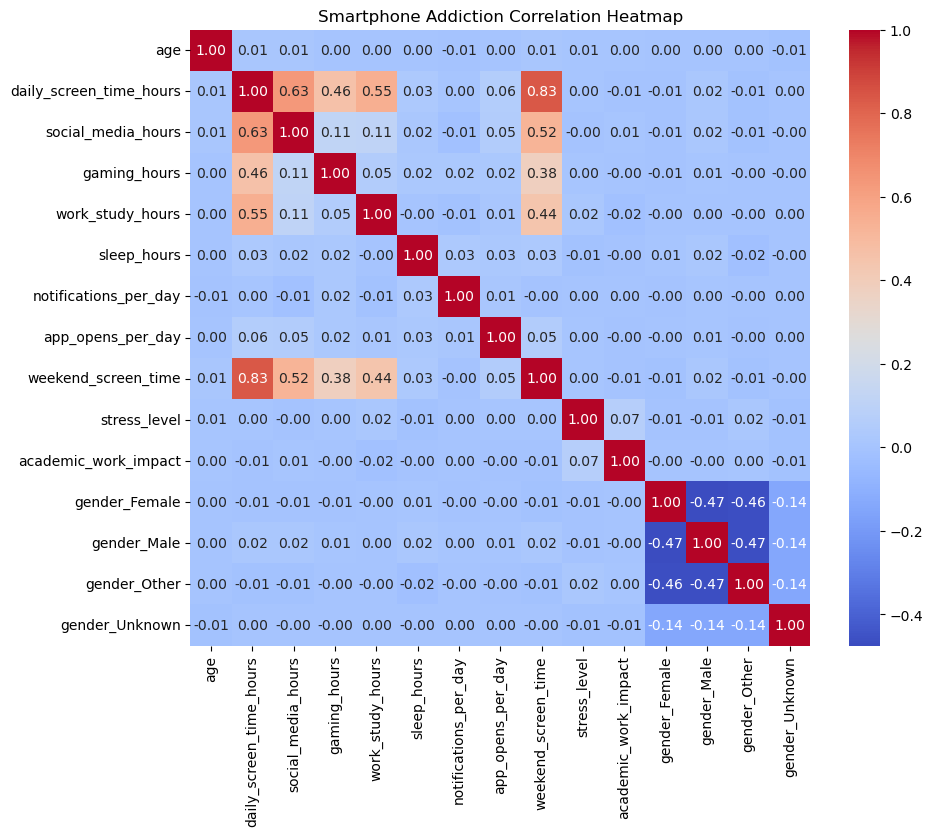

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Smartphone Addiction Correlation Heatmap")
plt.show()

In [17]:
xgb_model = XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

print("Starting Grid Search...")
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Starting Grid Search...
Best CV accuracy: 0.8955


In [18]:
best_xgb = grid_search.best_estimator_
predictions = best_xgb.predict(X_test_final)

submission = pd.DataFrame({
    'id': test_ids,
    'addicted_label': predictions
})

submission.to_csv('v1_submission.csv', index=False)
print("v1_submission.csv created successfully.")

v1_submission.csv created successfully.
